# Benchmark vs Sorcha ROC (n-body) — full sky, by elongation, by magnitude

One classifier (VDP, and digest2 as reference), two populations: the pure-S3M **benchmark**
(`benchmark_comparison_s3m_nbody.parquet`, 670,500 objects) vs **Sorcha case1**
(`sorcha_comparison_case1_nbody_Vband.parquet`, 648,769 tracklets, full 2-yr / 606 nights).
Both scored against the same n-body maps, in V.

Filter: `mag_bin_label.notna()` on both sides (objects outside the map's 14-25 mag range are
unscorable). Benchmark keeps 215,645/670,500 (32%); Sorcha keeps 648,296/648,769 (~100%, it's
already the detected set).

House style: x = completeness (%), y = contamination (%), lower-right is better. Colour = pipeline
(blue = benchmark, red = Sorcha); line style = classifier (solid = VDP, dashed = digest2).

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_auc_score

C_BENCH, C_SORCHA = 'tab:blue', 'tab:red'

def roc_xy(yy, s):
    """(completeness%, contamination%, bestF1, best_compl%, best_contam%)"""
    p, r, _ = precision_recall_curve(yy, s)
    f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r) > 0)
    bi = int(np.argmax(f1[:-1]))
    return r*100, (1-p)*100, f1[bi], r[bi]*100, (1-p[bi])*100

# ---- load, filter to scorable, add absdlon ----
bench = pd.read_parquet('benchmark_comparison_s3m_nbody.parquet',
    columns=['population','mag_bin_label','dlon_from_antisun_deg','P_NEO_vdp','P_NEO_d2'])
bench = bench[bench.mag_bin_label.notna()].copy()
bench['absdlon'] = bench.dlon_from_antisun_deg.abs()
bench['is_neo']  = (bench.population == 'NEO').astype(int)

sorcha = pd.read_parquet('sorcha_comparison_case1_nbody_Vband.parquet',
    columns=['population','mag_bin_label_Vband','prob_map_file','P_NEO_vdp_Vband','P_NEO_d2'])
sorcha = sorcha[sorcha.mag_bin_label_Vband.notna()].copy()
sorcha = sorcha.rename(columns={'mag_bin_label_Vband':'mag_bin_label','P_NEO_vdp_Vband':'P_NEO_vdp'})
def _absdlon(pmf):
    m = re.search(r'dlon([+-]\d+)', str(pmf))
    return abs(int(m.group(1))) if m else np.nan
sorcha['absdlon'] = sorcha.prob_map_file.map(_absdlon)
sorcha['is_neo']  = (sorcha.population == 'NEO').astype(int)

print(f'benchmark: {len(bench):,} scorable, {bench.is_neo.sum():,} NEO')
print(f'sorcha:    {len(sorcha):,} scorable, {sorcha.is_neo.sum():,} NEO  (full 2yr, 606 nights)')

benchmark: 215,645 scorable, 1,051 NEO
sorcha:    648,296 scorable, 148,634 NEO  (full 2yr, 606 nights)


## 1. Full-sky ROC

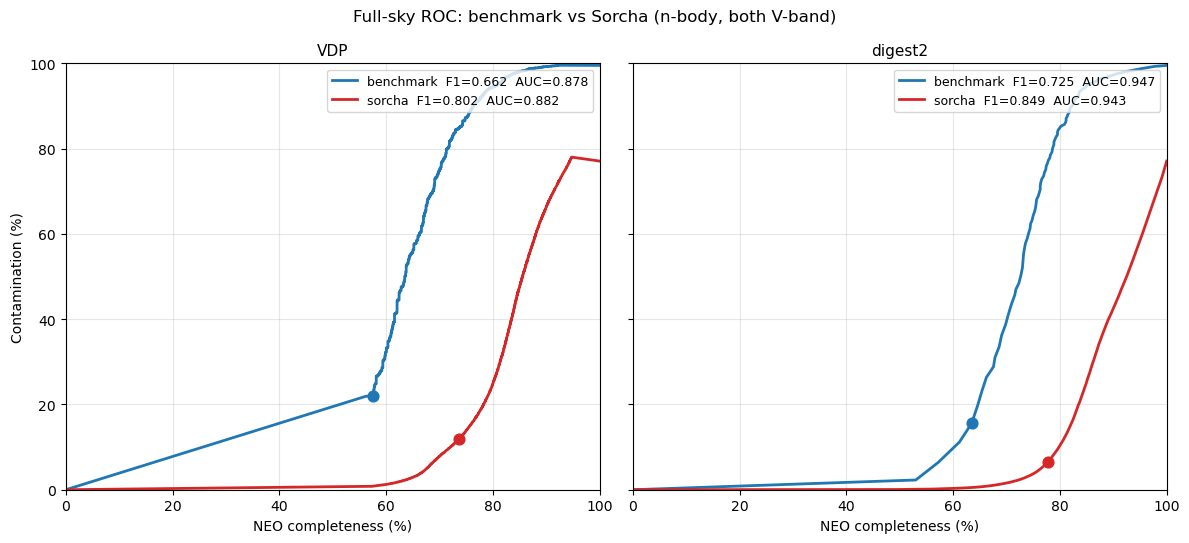

=== full-sky summary ===


N   N_NEO     F1    AUC  compl%  contam%
classifier dataset                                                 
VDP        benchmark  215645    1051  0.662  0.878    57.5     22.0
           sorcha     648296  148634  0.802  0.882    73.7     11.9
digest2    benchmark  215645    1051  0.725  0.947    63.5     15.6
           sorcha     648296  148634  0.849  0.943    77.8      6.6

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
rows = []
for ax, (score_col, title) in zip(axes, [('P_NEO_vdp','VDP'), ('P_NEO_d2','digest2')]):
    for df, name, col in [(bench,'benchmark',C_BENCH), (sorcha,'sorcha',C_SORCHA)]:
        yy = df.is_neo.values
        c, k, f1, mc, mk = roc_xy(yy, df[score_col].values)
        auc = roc_auc_score(yy, df[score_col].values)
        ax.plot(c, k, lw=2, color=col, label=f'{name}  F1={f1:.3f}  AUC={auc:.3f}')
        ax.scatter([mc], [mk], color=col, s=60, zorder=5)
        rows.append({'classifier': title, 'dataset': name, 'N': len(df), 'N_NEO': int(yy.sum()),
                     'F1': round(f1,3), 'AUC': round(auc,3), 'compl%': round(mc,1), 'contam%': round(mk,1)})
    ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)
    ax.set_xlabel('NEO completeness (%)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
axes[0].set_ylabel('Contamination (%)')
fig.suptitle('Full-sky ROC: benchmark vs Sorcha (n-body, both V-band)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_bvs_fullsky_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== full-sky summary ===')
display(pd.DataFrame(rows).set_index(['classifier','dataset']))

## 2. Broken by elongation ($|\Delta\lambda_\odot|$ from antisun)

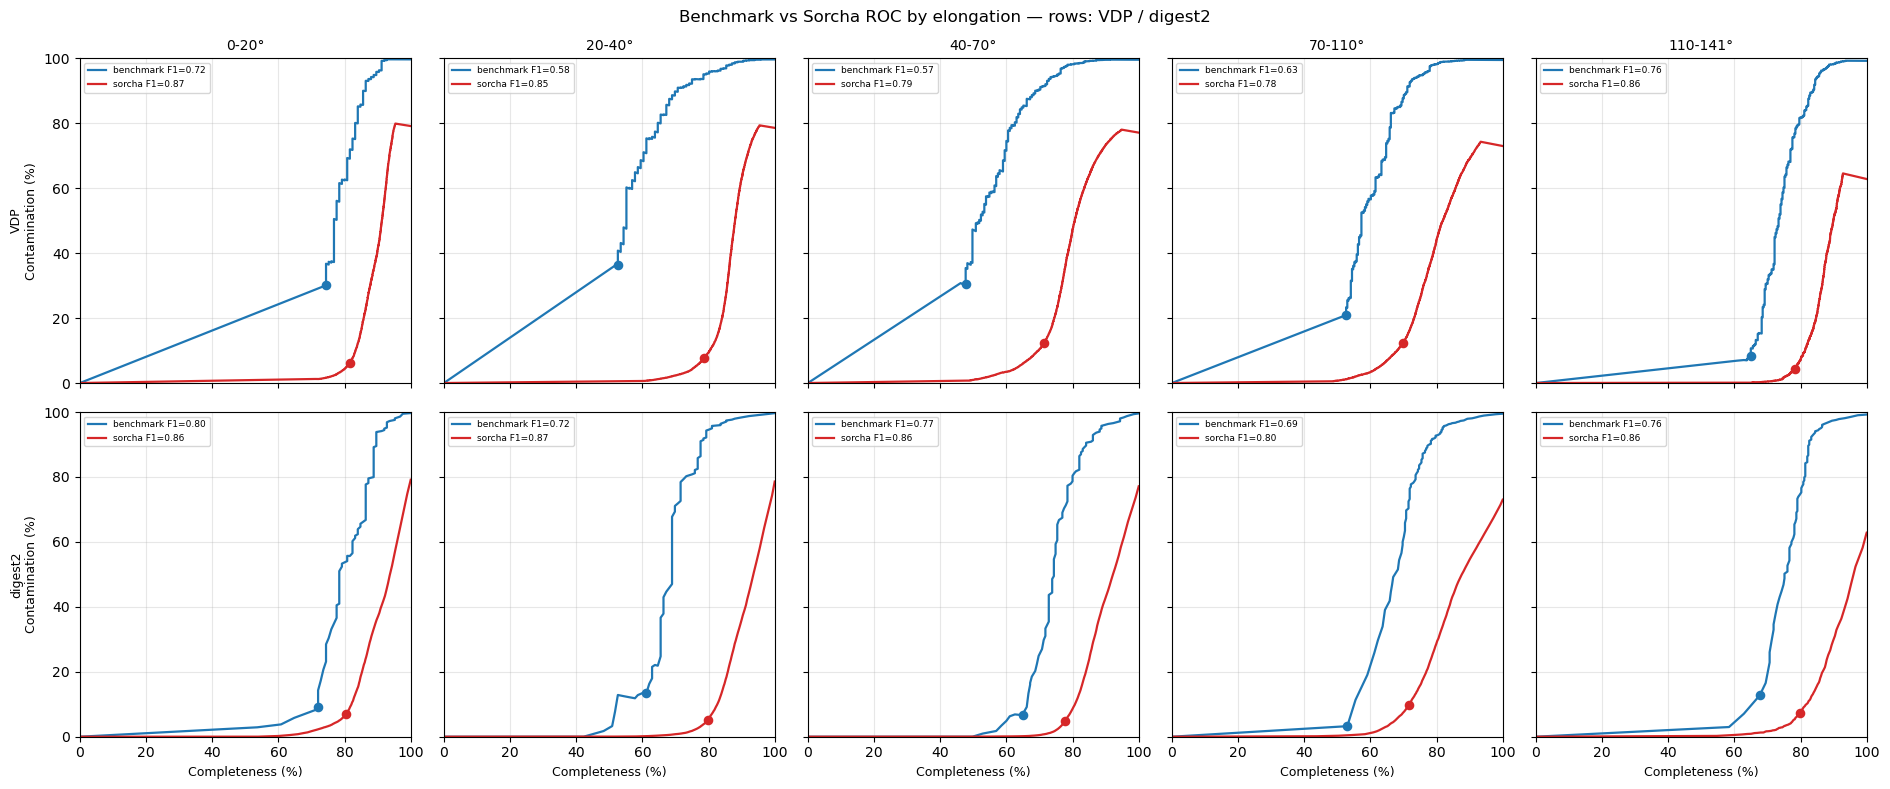

=== per-elongation summary ===


classifier       VDP          digest2       
dataset    benchmark sorcha benchmark sorcha
bin                                         
0-20°          0.721  0.873     0.804  0.863
110-141°       0.760  0.861     0.762  0.858
20-40°         0.575  0.850     0.717  0.866
40-70°         0.565  0.787     0.767  0.856
70-110°        0.632  0.778     0.685  0.798

In [3]:
BINS = [(0,20),(20,40),(40,70),(70,110),(110,141)]
BIN_LABS = ['0-20°','20-40°','40-70°','70-110°','110-141°']
MIN_NEO = 15

fig, axes = plt.subplots(2, len(BINS), figsize=(19, 8), sharex=True, sharey=True)
elong_rows = []
for ci, (score_col, title) in enumerate([('P_NEO_vdp','VDP'), ('P_NEO_d2','digest2')]):
    for bi, ((lo,hi), blab) in enumerate(zip(BINS, BIN_LABS)):
        ax = axes[ci, bi]
        for df, name, col in [(bench,'benchmark',C_BENCH), (sorcha,'sorcha',C_SORCHA)]:
            m = ((df.absdlon >= lo) & (df.absdlon < hi)).values
            yy = df.is_neo.values[m]
            if yy.sum() < MIN_NEO or (~yy.astype(bool)).sum() < MIN_NEO:
                continue
            c, k, f1, mc, mk = roc_xy(yy, df[score_col].values[m])
            ax.plot(c, k, lw=1.6, color=col, label=f'{name} F1={f1:.2f}')
            ax.scatter([mc],[mk], color=col, s=35, zorder=5)
            elong_rows.append({'classifier':title,'bin':blab,'dataset':name,
                               'N_NEO':int(yy.sum()),'F1':round(f1,3)})
        ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)
        ax.legend(fontsize=6.5, loc='upper left')
        if ci == 0: ax.set_title(blab, fontsize=10)
        if bi == 0: ax.set_ylabel(f'{title}\nContamination (%)', fontsize=9)
for ax in axes[-1,:]: ax.set_xlabel('Completeness (%)', fontsize=9)
fig.suptitle('Benchmark vs Sorcha ROC by elongation — rows: VDP / digest2', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_bvs_elongation_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== per-elongation summary ===')
display(pd.DataFrame(elong_rows).pivot_table(index=['bin'], columns=['classifier','dataset'], values='F1'))

## 3. Broken by magnitude bin

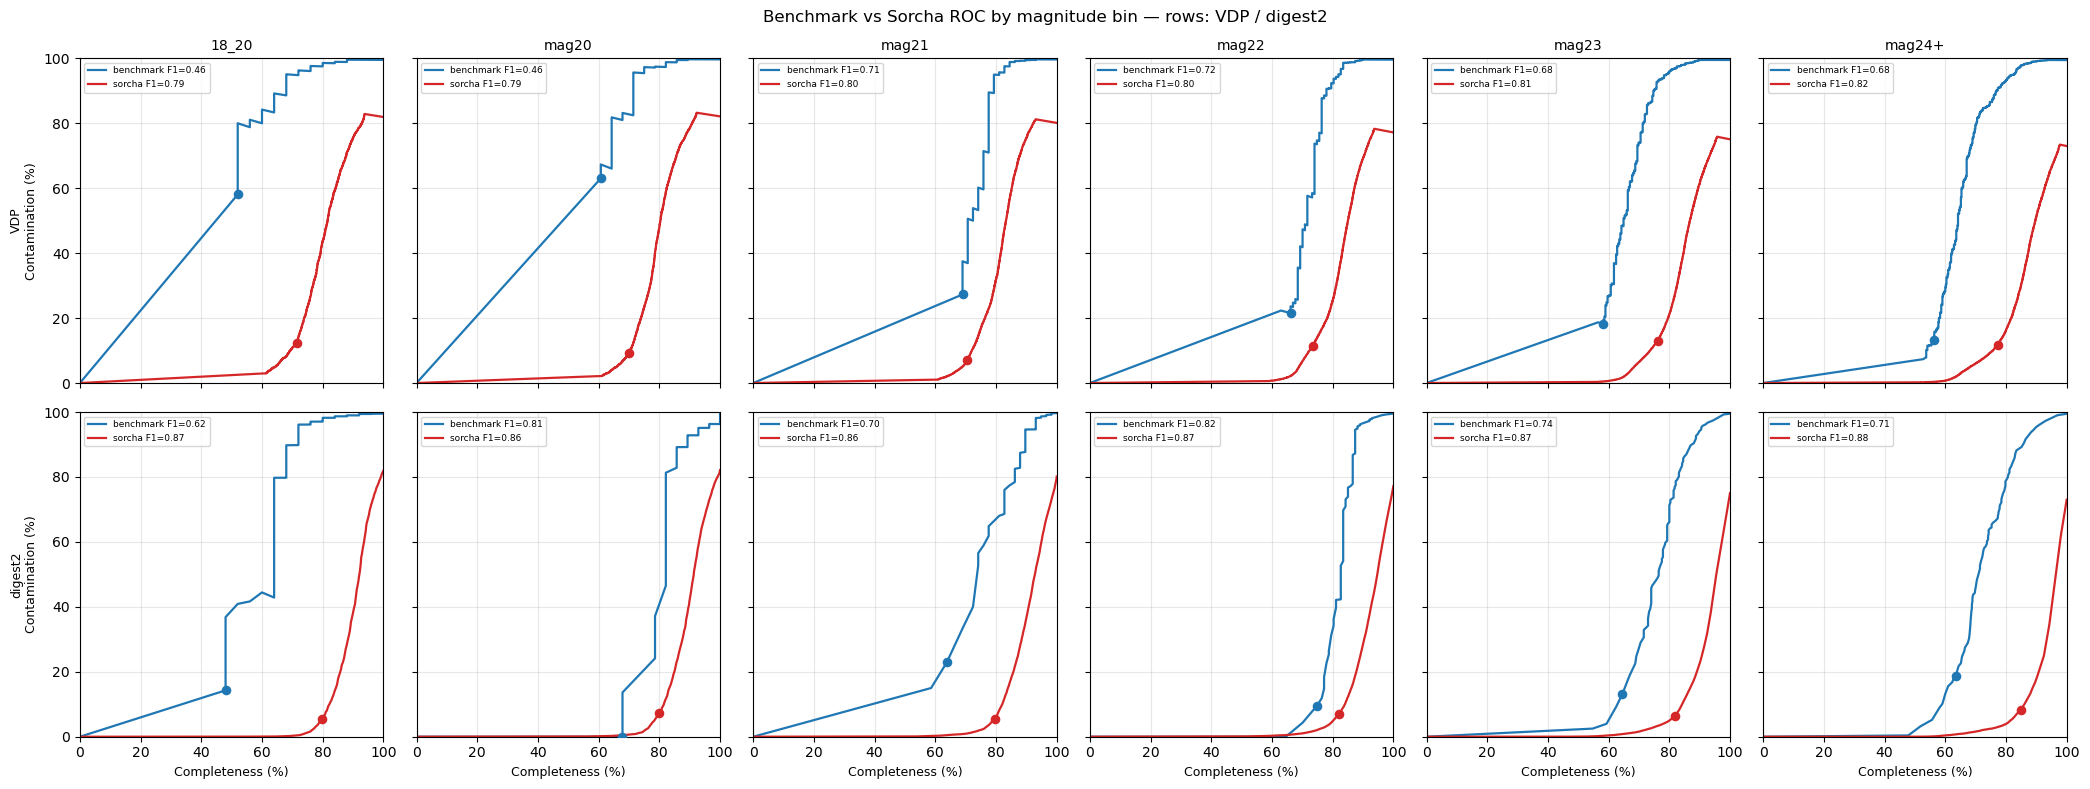

=== per-magnitude-bin summary ===


classifier       VDP          digest2       
dataset    benchmark sorcha benchmark sorcha
mag_bin                                     
18_20          0.464  0.786     0.615  0.865
mag20          0.459  0.790     0.809  0.859
mag21          0.708  0.802     0.698  0.864
mag22          0.718  0.803     0.819  0.872
mag23          0.680  0.812     0.740  0.873
mag24+         0.682  0.824     0.713  0.882

In [4]:
MAG_BINS = ['18_20','mag20','mag21','mag22','mag23','mag24+']

fig, axes = plt.subplots(2, len(MAG_BINS), figsize=(21, 8), sharex=True, sharey=True)
mag_rows = []
for ci, (score_col, title) in enumerate([('P_NEO_vdp','VDP'), ('P_NEO_d2','digest2')]):
    for bi, mb in enumerate(MAG_BINS):
        ax = axes[ci, bi]
        for df, name, col in [(bench,'benchmark',C_BENCH), (sorcha,'sorcha',C_SORCHA)]:
            m = (df.mag_bin_label == mb).values
            yy = df.is_neo.values[m]
            if yy.sum() < MIN_NEO or (~yy.astype(bool)).sum() < MIN_NEO:
                continue
            c, k, f1, mc, mk = roc_xy(yy, df[score_col].values[m])
            ax.plot(c, k, lw=1.6, color=col, label=f'{name} F1={f1:.2f}')
            ax.scatter([mc],[mk], color=col, s=35, zorder=5)
            mag_rows.append({'classifier':title,'mag_bin':mb,'dataset':name,
                             'N_NEO':int(yy.sum()),'F1':round(f1,3)})
        ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)
        ax.legend(fontsize=6.5, loc='upper left')
        if ci == 0: ax.set_title(mb, fontsize=10)
        if bi == 0: ax.set_ylabel(f'{title}\nContamination (%)', fontsize=9)
for ax in axes[-1,:]: ax.set_xlabel('Completeness (%)', fontsize=9)
fig.suptitle('Benchmark vs Sorcha ROC by magnitude bin — rows: VDP / digest2', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_bvs_magnitude_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== per-magnitude-bin summary ===')
display(pd.DataFrame(mag_rows).pivot_table(index=['mag_bin'], columns=['classifier','dataset'], values='F1'))

## 4. Same-object NEO score comparison (identity-matched, same epoch)

The full-sky ROC above compares two *different* NEO populations — the benchmark's 1,051 capped
NEOs vs Sorcha's 148,634 — so it can't tell us whether the two pipelines *agree on the same
object*. Here we restrict to the **same** NEOs, matched by identity (`s3m_objid == ObjID`),
**on the same night (MJD 61642)** — the benchmark is a snapshot at that epoch, so comparing to
Sorcha's tracklet from the same night is the fair, geometry-matched test (comparing to Sorcha's
score on a *different* night would mix in real orbital motion, not pipeline disagreement).

**61 of the 1,051 benchmark NEOs have a Sorcha tracklet on night 61642.**

In [5]:
# ---- benchmark NEOs (1051 scorable) with s3m_objid + scores ----
bfull = pd.read_parquet('benchmark_comparison_s3m_nbody.parquet',
    columns=['s3m_objid','population','mag_bin_label','P_NEO_vdp','P_NEO_d2'])
bneo = bfull[(bfull.mag_bin_label.notna()) & (bfull.population=='NEO')].copy()
bneo = bneo.rename(columns={'P_NEO_vdp':'P_vdp_bench','P_NEO_d2':'P_d2_bench'}).set_index('s3m_objid')

sfull = pd.read_parquet('sorcha_comparison_case1_nbody_Vband.parquet',
    columns=['ObjID','night','P_NEO_vdp_Vband','P_NEO_d2'])

# ---- SAME EPOCH: benchmark vs Sorcha night-61642 (clean same-object same-geometry) ----
snight = sfull[sfull.night==61642].set_index('ObjID')
same = bneo.join(snight[['P_NEO_vdp_Vband','P_NEO_d2']].rename(
        columns={'P_NEO_vdp_Vband':'P_vdp_sorcha','P_NEO_d2':'P_d2_sorcha'}), how='inner')
same['dP_vdp'] = same.P_vdp_sorcha - same.P_vdp_bench
same['dP_d2']  = same.P_d2_sorcha  - same.P_d2_bench

print(f'benchmark scorable NEOs: {len(bneo)}   with a Sorcha tracklet on night 61642: {len(same)}')
print(f'  VDP     |ΔP| median={same.dP_vdp.abs().median():.4f}  agree(<0.1)={100*(same.dP_vdp.abs()<0.1).mean():.1f}%')
print(f'  digest2 |ΔP| median={same.dP_d2.abs().median():.4f}  agree(<0.1)={100*(same.dP_d2.abs()<0.1).mean():.1f}%')

benchmark scorable NEOs: 1051   with a Sorcha tracklet on night 61642: 61
  VDP     |ΔP| median=0.0000  agree(<0.1)=91.8%
  digest2 |ΔP| median=0.0000  agree(<0.1)=86.9%


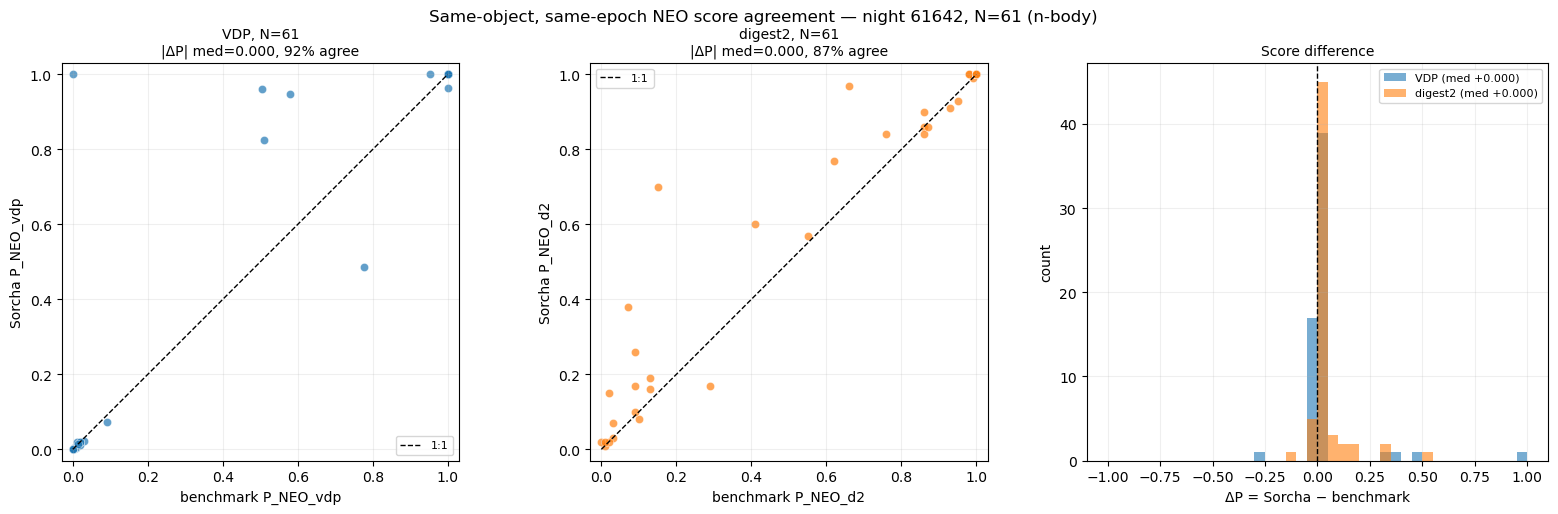

=== fraction each pipeline scores these NEOs as NEO (P>0.9) ===
  VDP:     benchmark 50.8%   sorcha 55.7%
  digest2: benchmark 59.0%   sorcha 60.7%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

# panel 1: VDP scatter, same object same epoch
ax = axes[0]
ax.scatter(same.P_vdp_bench, same.P_vdp_sorcha, s=35, alpha=0.7, color='tab:blue', edgecolors='white', linewidths=0.4)
ax.plot([0,1],[0,1],'k--',lw=1, label='1:1')
ax.set_xlabel('benchmark P_NEO_vdp'); ax.set_ylabel('Sorcha P_NEO_vdp')
ax.set_title(f'VDP, N={len(same)}\n|ΔP| med={same.dP_vdp.abs().median():.3f}, '
             f'{100*(same.dP_vdp.abs()<0.1).mean():.0f}% agree', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.2); ax.set_aspect('equal'); ax.set_xlim(-0.03,1.03); ax.set_ylim(-0.03,1.03)

# panel 2: digest2 scatter, same object same epoch
ax = axes[1]
ax.scatter(same.P_d2_bench, same.P_d2_sorcha, s=35, alpha=0.7, color='tab:orange', edgecolors='white', linewidths=0.4)
ax.plot([0,1],[0,1],'k--',lw=1, label='1:1')
ax.set_xlabel('benchmark P_NEO_d2'); ax.set_ylabel('Sorcha P_NEO_d2')
ax.set_title(f'digest2, N={len(same)}\n|ΔP| med={same.dP_d2.abs().median():.3f}, '
             f'{100*(same.dP_d2.abs()<0.1).mean():.0f}% agree', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.2); ax.set_aspect('equal'); ax.set_xlim(-0.03,1.03); ax.set_ylim(-0.03,1.03)

# panel 3: ΔP distributions, both classifiers
ax = axes[2]
bins = np.linspace(-1, 1, 41)
ax.hist(same.dP_vdp, bins=bins, alpha=0.6, color='tab:blue',   label=f'VDP (med {same.dP_vdp.median():+.3f})')
ax.hist(same.dP_d2,  bins=bins, alpha=0.6, color='tab:orange', label=f'digest2 (med {same.dP_d2.median():+.3f})')
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel('ΔP = Sorcha − benchmark'); ax.set_ylabel('count')
ax.set_title('Score difference', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.2)

fig.suptitle(f'Same-object, same-epoch NEO score agreement — night 61642, N={len(same)} (n-body)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_bvs_sameNEO_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== fraction each pipeline scores these NEOs as NEO (P>0.9) ===')
print(f'  VDP:     benchmark {100*(same.P_vdp_bench>0.9).mean():.1f}%   sorcha {100*(same.P_vdp_sorcha>0.9).mean():.1f}%')
print(f'  digest2: benchmark {100*(same.P_d2_bench>0.9).mean():.1f}%   sorcha {100*(same.P_d2_sorcha>0.9).mean():.1f}%')

## 5. Full object table — the 61 same-epoch NEOs

Every quantity for each of the 61 identity-matched, same-night NEOs: position (RA/Dec), ecliptic
rates (vlam/vbeta), magnitude, and both scores (VDP, digest2) on both sides, plus the position
offset (benchmark vs Sorcha, same epoch — should be small now that the integrator is fixed) and
the score differences.

In [7]:
# ---- pull full per-object columns for the 61 same-epoch NEOs ----
b_full = pd.read_parquet('benchmark_comparison_s3m_nbody.parquet',
    columns=['s3m_objid','mean_ra','mean_dec','vlam','vbeta','mean_mag','H','e',
             'P_NEO_vdp','P_NEO_d2']).set_index('s3m_objid')
s_full = pd.read_parquet('sorcha_comparison_case1_nbody_Vband.parquet',
    columns=['ObjID','night','mean_ra','mean_dec','vlam','vbeta','mean_mag_V',
             'P_NEO_vdp_Vband','P_NEO_d2'])
s_full = s_full[s_full.night == 61642].set_index('ObjID')

ids = same.index  # the 61 common NEOs
tbl = pd.DataFrame(index=ids)
tbl['ra_bench']   = b_full.loc[ids, 'mean_ra']
tbl['ra_sorcha']  = s_full.loc[ids, 'mean_ra']
tbl['dec_bench']  = b_full.loc[ids, 'mean_dec']
tbl['dec_sorcha'] = s_full.loc[ids, 'mean_dec']
tbl['vlam_bench']   = b_full.loc[ids, 'vlam']
tbl['vlam_sorcha']  = s_full.loc[ids, 'vlam']
tbl['vbeta_bench']  = b_full.loc[ids, 'vbeta']
tbl['vbeta_sorcha'] = s_full.loc[ids, 'vbeta']
tbl['mag_bench']  = b_full.loc[ids, 'mean_mag']
tbl['mag_sorcha'] = s_full.loc[ids, 'mean_mag_V']
tbl['H']  = b_full.loc[ids, 'H']
tbl['e']  = b_full.loc[ids, 'e']
tbl['P_vdp_bench']   = same.P_vdp_bench
tbl['P_vdp_sorcha']  = same.P_vdp_sorcha
tbl['P_d2_bench']    = same.P_d2_bench
tbl['P_d2_sorcha']   = same.P_d2_sorcha

# derived: sky separation (deg, small-angle), velocity offset, score diffs
import numpy as np
dra  = (tbl.ra_sorcha - tbl.ra_bench) * np.cos(np.radians(tbl.dec_bench))
ddec = tbl.dec_sorcha - tbl.dec_bench
tbl['sky_sep_deg'] = np.hypot(dra, ddec)
tbl['dv_deg_day']  = np.hypot(tbl.vlam_sorcha - tbl.vlam_bench, tbl.vbeta_sorcha - tbl.vbeta_bench)
tbl['dmag']    = tbl.mag_sorcha - tbl.mag_bench
tbl['dP_vdp']  = tbl.P_vdp_sorcha - tbl.P_vdp_bench
tbl['dP_d2']   = tbl.P_d2_sorcha  - tbl.P_d2_bench

tbl = tbl.round(4).sort_values('dP_vdp', key=lambda s: s.abs(), ascending=False)
print(f'{len(tbl)} identity-matched, same-epoch (night 61642) NEOs')
print(f"median sky-sep={tbl.sky_sep_deg.median():.4f} deg   median |dv|={tbl.dv_deg_day.median():.4f} deg/day   "
      f"median |dmag|={tbl.dmag.abs().median():.4f}")
display(tbl)

61 identity-matched, same-epoch (night 61642) NEOs
median sky-sep=0.0808 deg   median |dv|=0.0161 deg/day   median |dmag|=0.1103


,ra_bench,ra_sorcha,dec_bench,dec_sorcha,vlam_bench,vlam_sorcha,vbeta_bench,vbeta_sorcha,mag_bench,mag_sorcha,...,e,P_vdp_bench,P_vdp_sorcha,P_d2_bench,P_d2_sorcha,sky_sep_deg,dv_deg_day,dmag,dP_vdp,dP_d2
S0000e92a,48.2278,48.8249,-0.0958,0.2975,2.0022,1.9878,0.5900,0.6177,23.0359,23.8127,...,0.6380,0.0000,1.0000,1.00,1.00,0.7150,0.0313,0.7767,1.0000,0.00
S00000QBa,261.5778,261.5818,-28.2547,-28.2744,0.0834,0.0754,-0.3125,-0.3107,23.1377,23.2492,...,0.7137,0.5038,0.9617,0.62,0.77,0.0200,0.0082,0.1114,0.4579,0.15
S00007fva,313.2070,313.1562,-6.2413,-6.2547,-0.3024,-0.3127,0.0040,0.0072,24.4402,24.3084,...,0.6453,0.5781,0.9478,0.66,0.97,0.0523,0.0107,-0.1318,0.3697,0.31
S0000398a,14.1419,14.0735,-8.7501,-8.8102,-0.2695,-0.2861,-0.0909,-0.0843,23.2972,23.3425,...,0.4497,0.5096,0.8262,1.00,1.00,0.0905,0.0179,0.0453,0.3166,0.00
S0000dzba,38.2394,38.4373,-3.6475,-3.6242,0.5907,0.5705,-0.1235,-0.1167,24.2783,24.1684,...,0.3039,0.7761,0.4873,0.95,0.93,0.1989,0.0214,-0.1099,-0.2888,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00008Iwa,19.5952,19.7217,-13.3758,-13.4687,0.2880,0.2466,-0.4483,-0.4330,22.0891,22.1730,...,0.4095,1.0000,1.0000,0.93,0.91,0.1542,0.0441,0.0839,0.0000,-0.02
S000004za,276.7290,276.7210,-59.5541,-59.5394,-0.1602,-0.1733,0.6466,0.6461,19.5232,19.6722,...,0.4162,1.0000,1.0000,1.00,1.00,0.0153,0.0131,0.1490,0.0000,0.00
S0000an9a,349.8037,349.6834,-5.7561,-5.8058,-0.4667,-0.4806,0.0005,0.0068,24.2331,24.3796,...,0.5879,1.0000,1.0000,1.00,1.00,0.1296,0.0152,0.1466,0.0000,0.00
S00008N2a,50.0547,50.4595,-4.9397,-4.9540,1.1696,1.1561,-0.3510,-0.3459,23.6687,24.0234,...,0.5155,1.0000,1.0000,1.00,1.00,0.4036,0.0144,0.3548,0.0000,0.00


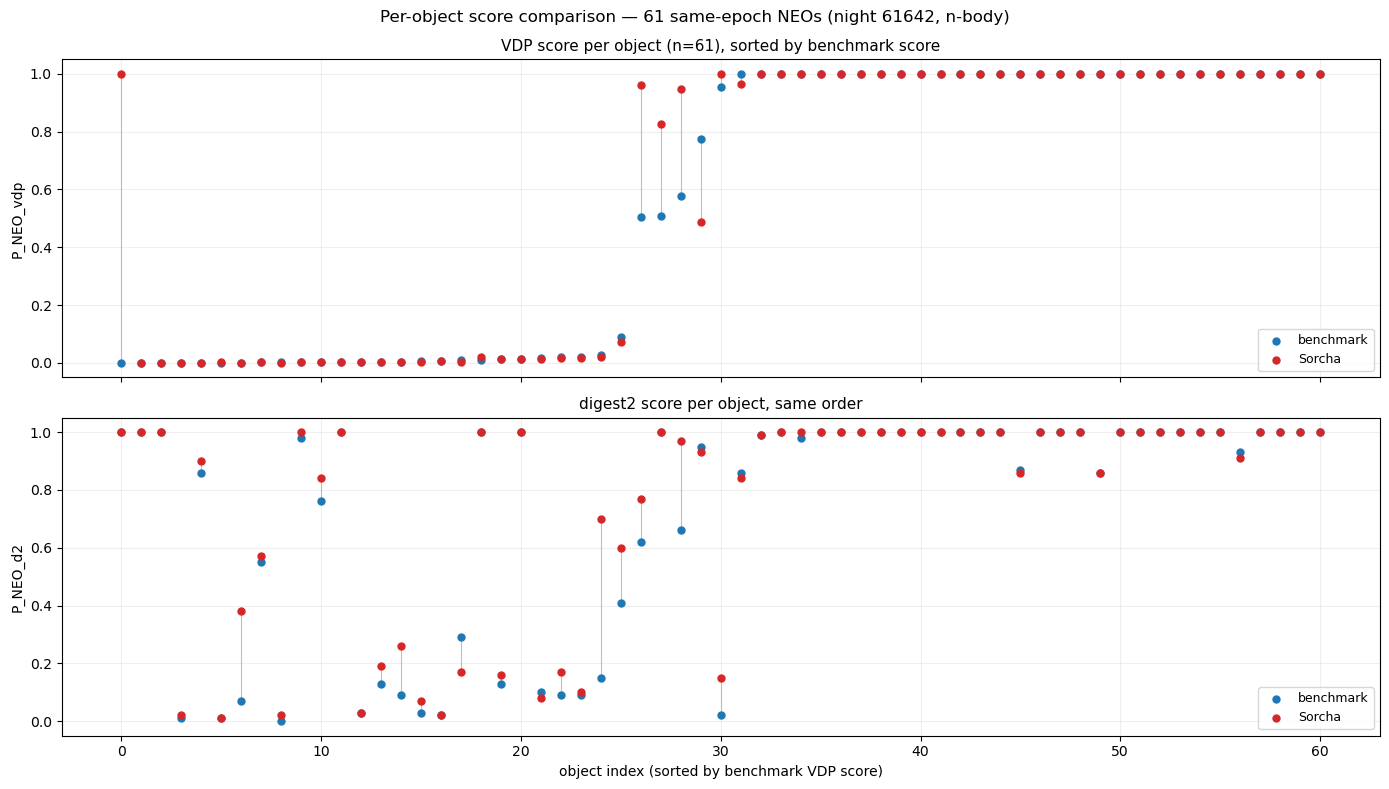

saved outputs/nbody_same_epoch_neo_table.csv


In [8]:
# ---- per-object comparison plot: both classifiers, benchmark vs sorcha, connected by object ----
plot_tbl = tbl.sort_values('P_vdp_bench')
x = np.arange(len(plot_tbl))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
for xi, (oid, row) in zip(x, plot_tbl.iterrows()):
    ax.plot([xi, xi], [row.P_vdp_bench, row.P_vdp_sorcha], color='grey', lw=0.8, alpha=0.5, zorder=1)
ax.scatter(x, plot_tbl.P_vdp_bench,  s=25, color='tab:blue',  label='benchmark', zorder=3)
ax.scatter(x, plot_tbl.P_vdp_sorcha, s=25, color='tab:red',   label='Sorcha',    zorder=3)
ax.set_ylabel('P_NEO_vdp'); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.set_title(f'VDP score per object (n={len(plot_tbl)}), sorted by benchmark score', fontsize=11)

ax = axes[1]
for xi, (oid, row) in zip(x, plot_tbl.iterrows()):
    ax.plot([xi, xi], [row.P_d2_bench, row.P_d2_sorcha], color='grey', lw=0.8, alpha=0.5, zorder=1)
ax.scatter(x, plot_tbl.P_d2_bench,  s=25, color='tab:blue',  label='benchmark', zorder=3)
ax.scatter(x, plot_tbl.P_d2_sorcha, s=25, color='tab:red',   label='Sorcha',    zorder=3)
ax.set_ylabel('P_NEO_d2'); ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('object index (sorted by benchmark VDP score)')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.set_title('digest2 score per object, same order', fontsize=11)

fig.suptitle(f'Per-object score comparison — 61 same-epoch NEOs (night 61642, n-body)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_bvs_sameNEO_perobject.png', dpi=150, bbox_inches='tight')
plt.show()

tbl.to_csv('outputs/nbody_same_epoch_neo_table.csv')
print('saved outputs/nbody_same_epoch_neo_table.csv')